In [5]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 59.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.7 MB/s eta 0:00:00:00:0100:01


In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer
from time import time
import numpy as np

## Arnold Map on a Classical Image

In [71]:
def arnold(image, iterations, a=1, b=1):
    height, width = image.shape
    mapping = {}

    for i in range(iterations):
        output = np.zeros((height, width), dtype=int)
        
        for x in range(height):
            for y in range(width):
                intensity = image[x,y]
                x_1 = (x+a*y)%height
                y_1 = (a*x+(a*b+1)*y)%width
                output[x_1,y_1] = intensity
                mapping[(x,y)]=(x_1,y_1)
                #print(f"Original:{x,y} Mapped to:{x_1,y_1}")

    image = output.copy()
    return image,mapping

In [72]:
def undo_arnold(image,iterations,a=1,b=1):
    height, width = image.shape
    #mapping = set()

    for i in range(iterations):
        output = np.zeros((height, width), dtype=int)
        
        for x in range(height):
            for y in range(width):
                intensity = image[x,y]
                x_1 = ((a*b+1)*x-a*y)%height
                y_1 = (-b*x+y)%width
                output[x_1,y_1] = intensity
                #mapping.add((x_1,y_1))
                #print(f"Original:{x,y} Mapped to:{x_1,y_1}")

    image = output.copy()
    return image

In [7]:
np.random.seed(42)
image = np.random.randint(0, 256, (4, 4), dtype=np.uint8)
image

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]], dtype=uint8)

In [8]:
img,mapping=arnold(image,1)
img

array([[102, 149,  98, 203],
       [243, 179, 220, 245],
       [225,  46,  92,  61],
       [  3, 234,  95,  14]])

In [10]:
img1,mapping = arnold(image,49)
img1

array([[102, 149,  98, 203],
       [243, 179, 220, 245],
       [225,  46,  92,  61],
       [  3, 234,  95,  14]])

In [11]:
undo_arnold(img1,49)

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]])

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

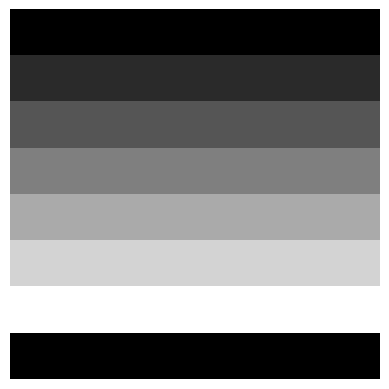

In [13]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 32,32
bands = 7
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

for i in range(bands):
    intensity = int(255 * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

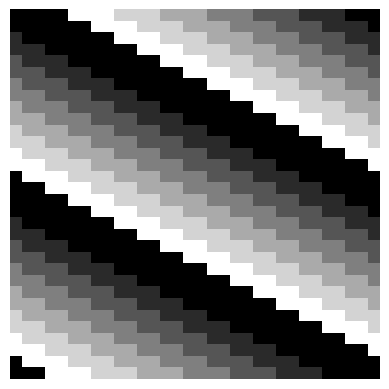

In [14]:
img1,mapping = arnold(image,10)
plt.imshow(img1,cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

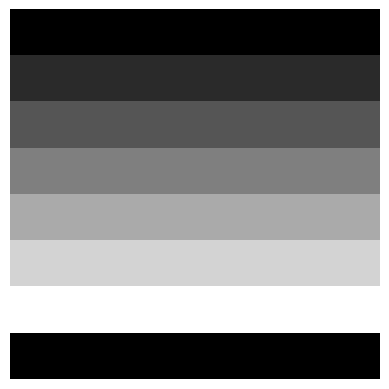

In [15]:
plt.imshow(undo_arnold(img1,10),cmap="gray")
plt.axis("off")

## NEQR Implementation with Arnold Transformation

In [9]:
from qiskit import QuantumCircuit, transpile,ClassicalRegister,QuantumRegister
from qiskit.circuit.library import DraperQFTAdder
from qiskit_aer import Aer
import numpy as np
from math import ceil,log

def neqr_setup_for_arnold(image):
    height,width=len(image),len(image[0])
    
    intensity_qubits=8
    n,m = ceil(log(height,2)), ceil(log(width,2))

    total_qubits=intensity_qubits+n+m
    classical_register = ClassicalRegister(intensity_qubits+n+m)

    qc = QuantumCircuit(total_qubits)
    qc.add_register(classical_register)

    intensity = list(range(8))
    row_qubits = list(range(8, 8+n))
    col_qubits = list(range(8+n, 8+n+m))
    
    pos_qubits = row_qubits + col_qubits

    for q in pos_qubits:
        qc.h(q)

    for i in range(height):  # Sending image to the Quantum Circuit
        for j in range(width):
            value=image[i,j]
            value=format(value,"08b")

            i_bits,j_bits = format(i,f'0{n}b'), format(j, f'0{m}b')
            pos_bits = i_bits+j_bits

            for ix, bit in enumerate(pos_bits):
                if bit == '0':
                    qc.x(pos_qubits[ix])

            for idx, bit in enumerate(value[::-1]): 
                if bit == '1':
                    qc.mcx(pos_qubits, idx)

            for ix, bit in enumerate(pos_bits):
                if bit == '0':
                    qc.x(pos_qubits[ix])        
                    
            qc.barrier()

    return qc,n,m,row_qubits,col_qubits

In [10]:
def visualize_results(qc,number):
    qc.measure(range(number),range(number))
    aer_sim = Aer.get_backend('aer_simulator')
    t_qc_image = transpile(qc, aer_sim)
    job_neqr = aer_sim.run(t_qc_image,shots=1024)
    result_neqr = job_neqr.result()
    counts_neqr = result_neqr.get_counts()

    return counts_neqr

In [11]:
def decode_neqr(counts, height, width):
    n = int(np.ceil(np.log2(height)))
    m = int(np.ceil(np.log2(width)))

    image = np.zeros((height, width), dtype=int)

    for bitstring, count in counts.items():

        intensity_bits = bitstring[n+m:]
        pos_bits = bitstring[:n+m]

        height_bits = pos_bits[n:][::-1]
        width_bits = pos_bits[:n][::-1]

        x = int(height_bits, 2)
        y = int(width_bits, 2)
        #print(x,y,int(intensity_bits, 2))

        image[x,y] = int(intensity_bits, 2)

    return image

In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import DraperQFTAdder

def arnold_block(n,m,a=1,b=1):
    qc = QuantumCircuit(n+m)
    # Arnold Transform

    x = list(range(0, n))
    y = list(range(n, n+m))

    adder = DraperQFTAdder(n)
    
    for i in range(a): # x' = x+ay
        qc.append(adder, y[::-1] + x[::-1])

    for i in range(b): # y' = bx + (ab+1)y = bx+aby+y = y+ b(x+ay) = y+bx'
        qc.append(adder, x[::-1] + y[::-1])
        
    return qc

In [13]:
np.random.seed(42)
image = np.random.randint(0, 256, (4, 4), dtype=np.uint8)
image

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]], dtype=uint8)

In [14]:
qc, n, m, x, y = neqr_setup_for_arnold(image) #Checking if NEQR Works and all fucntions work
counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

In [15]:
img_array

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]])

### Example 1

In [16]:
np.random.seed(42)
image = np.random.randint(0, 256, (4, 4), dtype=np.uint8)
image

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]], dtype=uint8)

In [17]:
qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y
qc.append(arn, qubits)

In [18]:
counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)
img_array

array([[102, 149,  98, 203],
       [243, 179, 220, 245],
       [225,  46,  92,  61],
       [  3, 234,  95,  14]])

In [19]:
start = time()

qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y 
qc.append(arn, qubits)
qc.append(arn.inverse(), qubits)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

end=time()

print(img_array, f"{end-start:.3f}")

[[102 220 225  95]
 [179  61 234 203]
 [ 92   3  98 243]
 [ 14 149 245  46]] 0.162


In [20]:
start = time()

qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y 

for i in range(10):
    qc.append(arn, qubits)

for i in range(10):
    qc.append(arn.inverse(), qubits)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

end=time()

print(img_array, f"{end-start:.3f}")

[[102 220 225  95]
 [179  61 234 203]
 [ 92   3  98 243]
 [ 14 149 245  46]] 0.342


In [21]:
qc.num_qubits

12

### Example 2

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

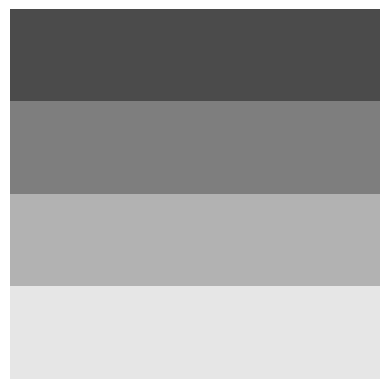

In [22]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 8,8
bands = 4
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

min_val = 75
max_val = 230

for i in range(bands):
    intensity = int(min_val + (max_val - min_val) * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [23]:
qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y

qc.append(arn, qubits)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y

for i in range(10):
    qc.append(arn, qubits)

counts=visualize_results(qc,n+m+8)
tenarn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)
arn = arnold_block(n, m)

qubits = x + y

for i in range(10):
    qc.append(arn, qubits)

for i in range(10):
    qc.append(arn.inverse(), qubits)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

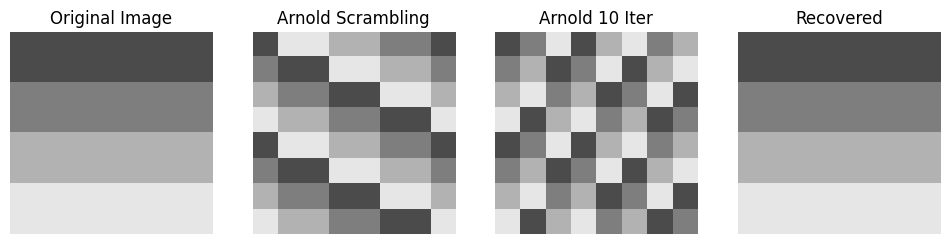

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(tenarn_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold 10 Iter")
axes[2].axis('off')

axes[3].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Recovered")
axes[3].axis('off')

### Example 3

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

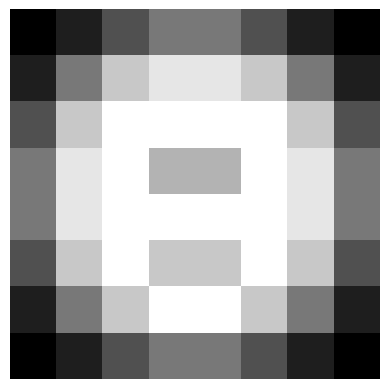

In [37]:
import numpy as np
import matplotlib.pyplot as plt

puppy = np.array([
    [  0,  30,  80, 120, 120,  80,  30,   0],
    [ 30, 120, 200, 230, 230, 200, 120,  30],
    [ 80, 200, 255, 255, 255, 255, 200,  80],
    [120, 230, 255, 180, 180, 255, 230, 120],
    [120, 230, 255, 255, 255, 255, 230, 120],
    [ 80, 200, 255, 200, 200, 255, 200,  80],
    [ 30, 120, 200, 255, 255, 200, 120,  30],
    [  0,  30,  80, 120, 120,  80,  30,   0]
], dtype=np.uint8)

plt.imshow(puppy, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [42]:
qc, n, m, x, y = neqr_setup_for_arnold(puppy)
arn = arnold_block(n, m)

qubits = x + y

qc.append(arn, qubits)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)
arn = arnold_block(n, m)

qubits = x + y

for i in range(10):
    qc.append(arn, qubits)

counts=visualize_results(qc,n+m+8)
tenarn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)
arn = arnold_block(n, m)

qubits = x + y

for i in range(10):
    qc.append(arn, qubits)

for i in range(10):
    qc.append(arn.inverse(), qubits)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

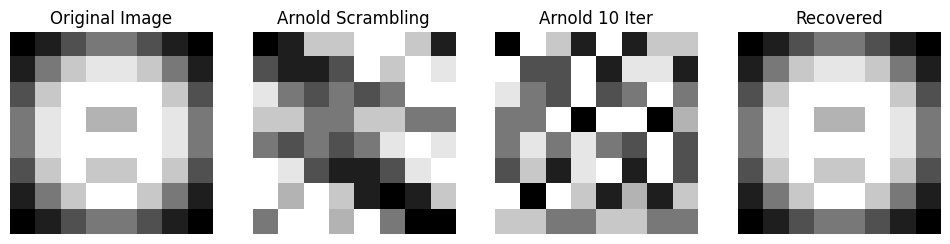

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(puppy, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(tenarn_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold 10 Iter")
axes[2].axis('off')

axes[3].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Recovered")
axes[3].axis('off')

## Random Sequence Generation

In [45]:
import hashlib
import numpy as np
from math import sin,cos,floor

def generate_sequence_values(image,alpha=1,beta=1):
    height,width = image.shape
    n,m = ceil(log(height,2)), ceil(log(width,2))
    
    arr = np.asarray(image, dtype=np.uint8)
    arr = np.ascontiguousarray(arr)
    hash_value = hashlib.sha256(arr.tobytes()).hexdigest()

    h1 = int(hash_value[48:],16)/(2**14)
    h2 = int(hash_value[32:48],16)/(2**14)
    g1 = int(hash_value[16:32],16)/(2**14)
    g2 = int(hash_value[:16],16)/(2**14)
    t = np.sum(image)/(255*(2**(2*n)))

    x_0 = float((h1+t+1)%1)
    y_0 = float((h2+t+1)%1)
    z_0 = float((g1+g2+t+1)%1)

    seq=[(x_0,y_0,z_0)]
    loop = height*width
    for _ in range(loop-1):
        x_1 = cos(alpha*x_0)*sin(1/(y_0*((1-z_0)**2)))
        y_1 = cos(alpha*x_0*y_0+beta*z_0)
        z_1 = x_0
        seq.append((x_1,y_1,z_1))
        x_0,y_0,z_0 = x_1,y_1,z_1

    n = len(seq)
    output = []
    counter = 0
    idx = 0
    while len(output)!=n:
        output.append(seq[counter][idx])
        counter = (counter+5)%n
        idx = (idx+1)%3

    result = []
    for i in range(n):
        L = floor(output[i]*(10**14))%256
        result.append(f"{L:08b}")

    return result

## Quantum XOR Block

In [46]:
def quantum_xor_block(seq, pos_qubits, intensity_qubits):
    qc = QuantumCircuit(8+len(pos_qubits))
    for pixel_index, bitstring in enumerate(seq):

        # Convert pixel index → binary
        binary_index = format(pixel_index, f'0{len(pos_qubits)}b')

        # Apply X to match control state (for 0-controls)
        for i, bit in enumerate(binary_index):
            if bit == '0':
                qc.x(pos_qubits[i])

        # Apply XOR on intensity bits
        for j, bit in enumerate(bitstring):
            if bit == '1':
                qc.mcx(pos_qubits, intensity_qubits[j])

        # Undo X gates
        for i, bit in enumerate(binary_index):
            if bit == '0':
                qc.x(pos_qubits[i])

    return qc

### Example 1

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

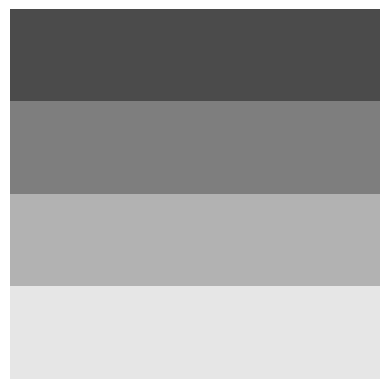

In [47]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 8,8
bands = 4
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

min_val = 75
max_val = 230

for i in range(bands):
    intensity = int(min_val + (max_val - min_val) * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [50]:
seq = generate_sequence_values(image)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
#xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
#qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
xor_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################


qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

qc.append(xor.inverse(),qubits_xor)
qc.append(arn.inverse(), qubits_arn)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

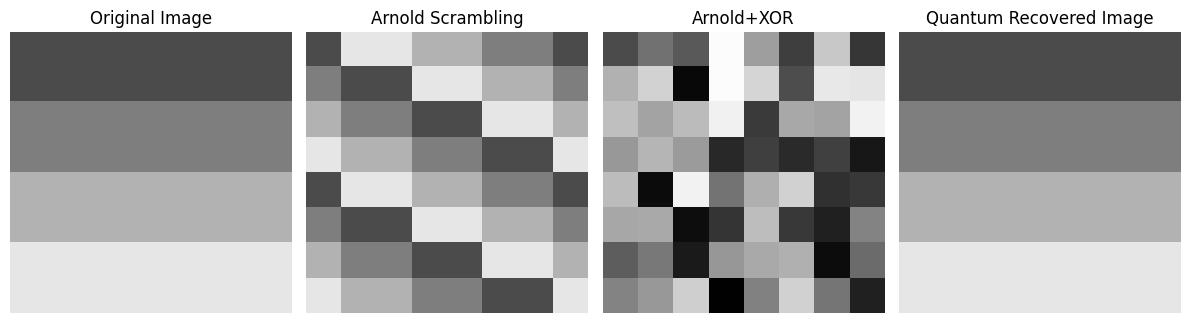

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Quantum Recovered Image")
axes[3].axis('off')

plt.tight_layout()
plt.show()

### Example 2

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

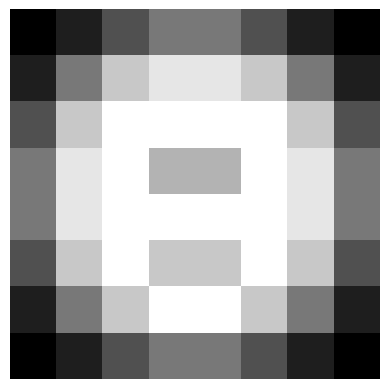

In [52]:
import numpy as np
import matplotlib.pyplot as plt

puppy = np.array([
    [  0,  30,  80, 120, 120,  80,  30,   0],
    [ 30, 120, 200, 230, 230, 200, 120,  30],
    [ 80, 200, 255, 255, 255, 255, 200,  80],
    [120, 230, 255, 180, 180, 255, 230, 120],
    [120, 230, 255, 255, 255, 255, 230, 120],
    [ 80, 200, 255, 200, 200, 255, 200,  80],
    [ 30, 120, 200, 255, 255, 200, 120,  30],
    [  0,  30,  80, 120, 120,  80,  30,   0]
], dtype=np.uint8)

plt.imshow(puppy, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [53]:
seq = generate_sequence_values(puppy)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
#xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
#qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
xor_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

qc.append(xor.inverse(),qubits_xor)
qc.append(arn.inverse(), qubits_arn)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

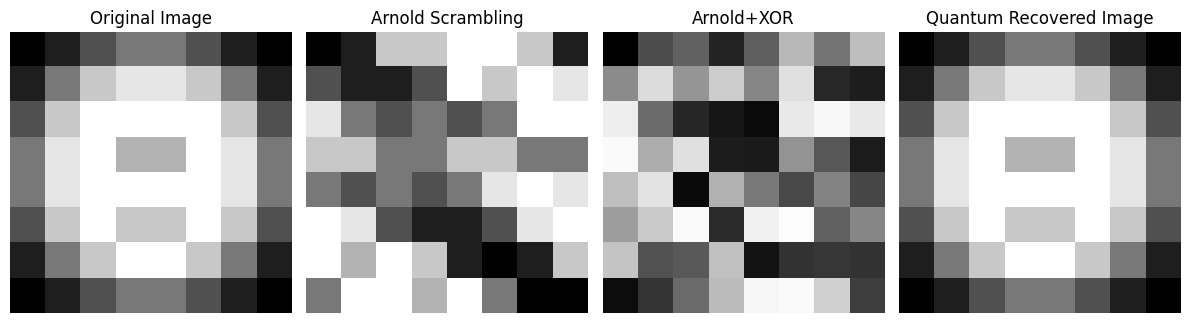

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(puppy, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Quantum Recovered Image")
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Scrambling Functions

In [56]:
def qubit_level_shift_scrambling():
    qc= QuantumCircuit(8)
    
    qc.swap(4,7)
    qc.swap(3,6)
    qc.swap(2,5)
    qc.swap(4,1)
    qc.swap(2,0)
    qc.swap(5,4)
    qc.swap(3,2)
    qc.swap(1,0)

    return qc

In [57]:
def qubit_xor_scrambling():
    qc = QuantumCircuit(8)

    qc.cx(7,0)
    qc.cx(6,1)
    qc.cx(5,2)
    qc.cx(4,3)
    qc.cx(5,0)
    qc.swap(7,2)
    qc.swap(6,4)
    qc.swap(5,1)
    qc.swap(3,0)
    qc.swap(1,0)
    qc.swap(4,1)

    return qc

In [58]:
def controlled_qubit_level_based_scrambling(seq,pos_qubits,intensity_qubits):
    qc = QuantumCircuit(8+len(pos_qubits))
    for pixel_index, bitstring in enumerate(seq):

        # Convert pixel index → binary
        binary_index = format(pixel_index, f'0{len(pos_qubits)}b')

        # Apply X to match control state (for 0-controls)
        for i, bit in enumerate(binary_index):
            if bit == '0':
                qc.x(pos_qubits[i])

        # Apply XOR on intensity bits
        # for j, bit in enumerate(bitstring):
        #     if bit == '1':
        #         qc.mcx(pos_qubits, intensity_qubits[j])
        cs = int(bitstring,2)%5
        if cs%2 == 0:
            qc.swap(4,7)
            qc.swap(3,6)
            qc.swap(2,5)
            qc.swap(4,1)
            qc.swap(2,0)
            qc.swap(5,4)
            qc.swap(3,2)
            qc.swap(1,0)
        else:
            qc.cx(7,0)
            qc.cx(6,1)
            qc.cx(5,2)
            qc.cx(4,3)
            qc.cx(5,0)
            qc.swap(7,2)
            qc.swap(6,4)
            qc.swap(5,1)
            qc.swap(3,0)
            qc.swap(1,0)
            qc.swap(4,1)

        # Undo X gates
        for i, bit in enumerate(binary_index):
            if bit == '0':
                qc.x(pos_qubits[i])

    return qc

## Full Encryption Examples

### Example 1

In [59]:
np.random.seed(42)
image = np.random.randint(0, 256, (4, 4), dtype=np.uint8)
image

array([[102, 220, 225,  95],
       [179,  61, 234, 203],
       [ 92,   3,  98, 243],
       [ 14, 149, 245,  46]], dtype=uint8)

(np.float64(-0.5), np.float64(3.5), np.float64(3.5), np.float64(-0.5))

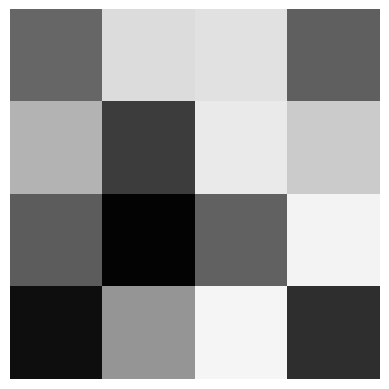

In [60]:
plt.imshow(image,cmap="gray",vmin=0,vmax=255)
plt.axis("off")

In [62]:
seq = generate_sequence_values(image)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
#xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
#qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
xor_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

# qc.append(scr.inverse(),qubits_scr)
# qc.append(xor.inverse(),qubits_xor)
# qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
scr_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

qc.append(scr.inverse(),qubits_scr)
qc.append(xor.inverse(),qubits_xor)
qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

(np.float64(-0.5), np.float64(3.5), np.float64(3.5), np.float64(-0.5))

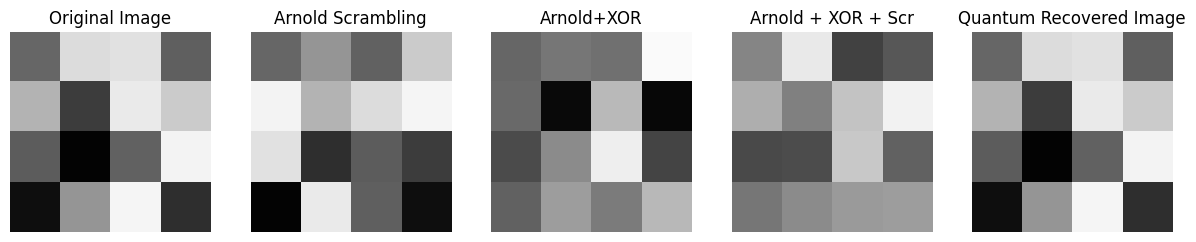

In [63]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')

In [64]:
image == img_array

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

### Example 2

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

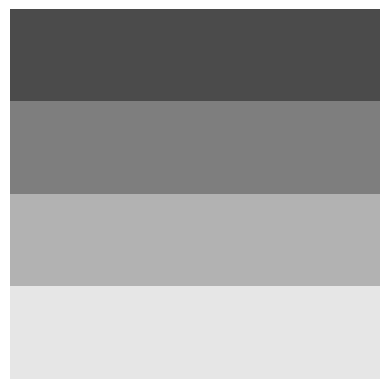

In [65]:
import numpy as np
import matplotlib.pyplot as plt

height, width = 8,8
bands = 4
band_height = height // bands

image = np.zeros((height, width), dtype=np.uint8)

min_val = 75
max_val = 230

for i in range(bands):
    intensity = int(min_val + (max_val - min_val) * i / (bands - 1))
    image[i * band_height:(i + 1) * band_height, :] = intensity

plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

In [66]:
seq = generate_sequence_values(image)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
#xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
#qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
xor_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

# qc.append(scr.inverse(),qubits_scr)
# qc.append(xor.inverse(),qubits_xor)
# qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
scr_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(image)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

qc.append(scr.inverse(),qubits_scr)
qc.append(xor.inverse(),qubits_xor)
qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

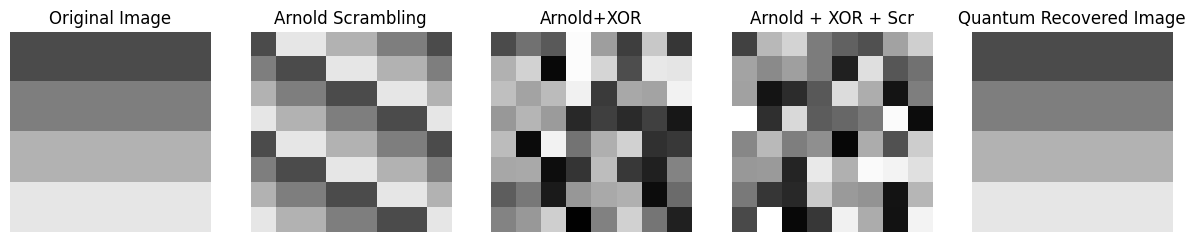

In [67]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')

### Example 3

In [68]:
seq = generate_sequence_values(puppy)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
#xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
#qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
arn_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)

counts=visualize_results(qc,n+m+8)
xor_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

# qc.append(scr.inverse(),qubits_scr)
# qc.append(xor.inverse(),qubits_xor)
# qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
scr_img_array=decode_neqr(counts,2**n,2**m)

#############################################################################

qc, n, m, x, y = neqr_setup_for_arnold(puppy)

qubits_arn = x + y
qubits_xor = list(range(8)) + x + y
qubits_scr = list(range(8)) + x + y

arn = arnold_block(n, m)
xor = quantum_xor_block(seq,x+y,list(range(8)))
scr = controlled_qubit_level_based_scrambling(seq,x+y,list(range(8)))

qc.append(arn, qubits_arn)
qc.append(xor,qubits_xor)
qc.append(scr, qubits_scr)

qc.append(scr.inverse(),qubits_scr)
qc.append(xor.inverse(),qubits_xor)
qc.append(arn.inverse(),qubits_arn)

counts=visualize_results(qc,n+m+8)
img_array=decode_neqr(counts,2**n,2**m)

(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

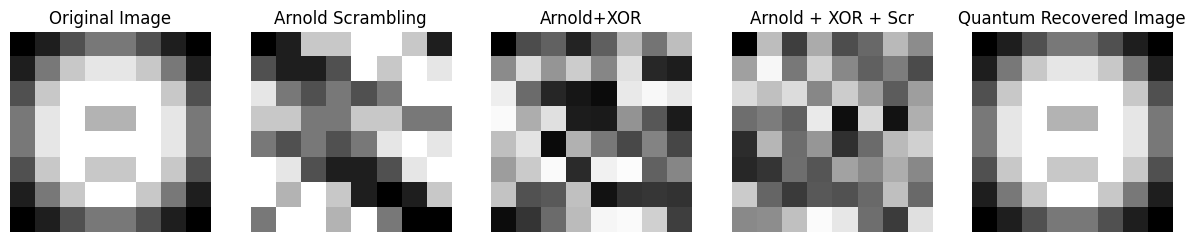

In [69]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(puppy, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(arn_img_array, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Arnold Scrambling")
axes[1].axis('off')

axes[2].imshow(xor_img_array, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Arnold+XOR")
axes[2].axis('off')

axes[3].imshow(scr_img_array, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Arnold + XOR + Scr")
axes[3].axis('off')

axes[4].imshow(img_array, cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Quantum Recovered Image")
axes[4].axis('off')